### Cell 1: Setup & Feature Engineering

This cell prepares the dataset for analysis by loading the generated listening history and creating a few core features that are used throughout the notebook.

First, the synthetic Spotify-style dataset (my_spotify_data.csv) is loaded and the timestamp column is converted into a proper datetime format. This allows time-based information, such as the hour of listening, to be extracted reliably.

Next, listening events are grouped into custom time-of-day categories. These categories are intentionally designed around my personal routine rather than standard definitions (for example, the early morning hours represent a sleep window rather than active listening).

Finally, a boolean flag is created to isolate a specific emotional disruption period. This flag makes it easy to compare listening behavior during that window against the rest of the timeline in later analysis.

By the end of this cell, the dataset is enriched with time-based and contextual features that form the foundation for all subsequent exploration and modeling.

In [19]:
# --- CELL 1: SETUP & FEATURE ENGINEERING ---

import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt


# Set a consistent visual style for plots
sns.set_theme(style="whitegrid", palette="muted")


# Load the generated listening dataset
try:
    df = pd.read_csv('../data/my_spotify_data.csv')

    # Parse timestamps so time-based features can be extracted
    df['timestamp'] = pd.to_datetime(
        df['timestamp'],
        dayfirst=True,
        format='mixed'
    )
    
    print("Data loaded successfully!")

except FileNotFoundError:
    print("Error: File not found. Check if 'my_spotify_data.csv' is in the '../data/' folder.")
except Exception as e:
    print(f"Something went wrong: {e}")


# Assign custom time-of-day labels based on listening routine
def get_time_period(hour):
    if 0 <= hour < 3:
        return "Late Night"
    elif 3 <= hour < 12:
        return "Morning"
    elif 12 <= hour < 17:
        return "Afternoon"
    elif 17 <= hour < 21:
        return "Evening"
    else:
        return "Night"


# Create time-based features
df['hour'] = df['timestamp'].dt.hour
df['time_period'] = df['hour'].apply(get_time_period)


# Flag the emotional disruption period for later comparison
start_date = pd.Timestamp("2026-01-19")
end_date = pd.Timestamp("2026-01-31")

df['is_heartbreak_week'] = (
    (df['timestamp'] >= start_date) &
    (df['timestamp'] <= end_date)
)


# Quick sanity check
print(f"Total Rows: {len(df)}")
display(df.head(5))


Data loaded successfully!
Total Rows: 1203


,timestamp,song_name,artist,valence,energy,hour,time_period,is_heartbreak_week
0,2025-11-01 00:05:00,Serendipity,BTS,0.23,0.58,0,Late Night,False
1,2025-11-01 00:08:00,ONLY,LeeHi,0.15,0.30,0,Late Night,False
2,2025-11-01 00:11:00,Die With A Smile,Lady Gaga,0.54,0.59,0,Late Night,False
3,2025-11-01 00:14:00,Brooklyn Baby,Lana Del Rey,0.09,0.66,0,Late Night,False
4,2025-11-02 12:08:00,São Paulo,The Weekend,0.55,0.66,12,Afternoon,False


### Cell 2: Time of Day vs Happiness Scores

After creating time-based features, this section examines whether listening behavior changes across different parts of the day.

By grouping listening events into custom time-of-day categories, we compare average song happiness (valence) to understand how mood varies throughout the day based on my listening routine.

Average happiness sorted by score:


,time_period,valence
2,Late Night,0.27
3,Morning,0.32
4,Night,0.40
1,Evening,0.45
0,Afternoon,0.49


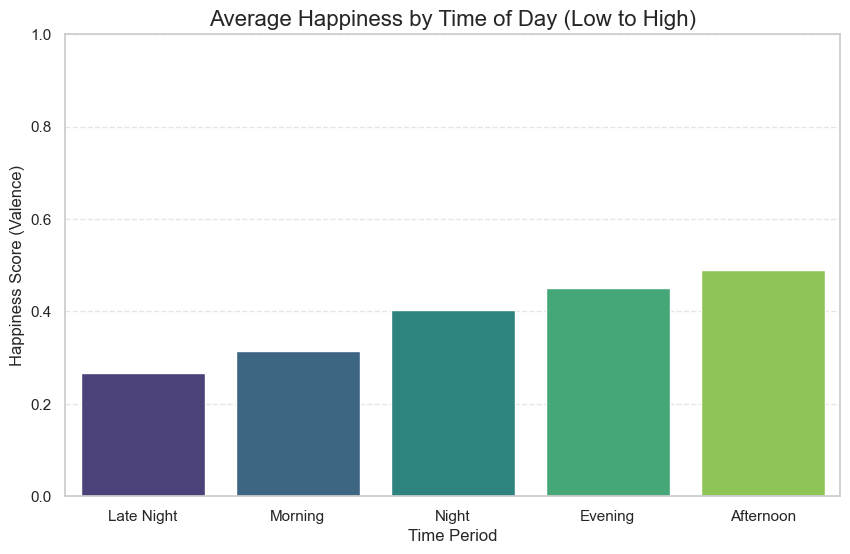

In [20]:
# --- CELL 2: TIME OF DAY VS HAPPINESS ---

# 1. Calculate average valence (happiness) by time period
time_mood_summary = (
    df.groupby('time_period')['valence']
    .mean()
    .reset_index()
)

# 2. SORT the data: Smallest happiness -> Highest happiness
time_mood_sorted = time_mood_summary.sort_values('valence', ascending=True)

print("Average happiness sorted by score:")
# Display table rounded to 2 decimal places
display(time_mood_sorted.style.format({'valence': '{:.2f}'}))

# 3. Plot
plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=time_mood_sorted,
    x='time_period',
    y='valence',
    palette='viridis',
    hue='time_period'  # Adds the color variation
)

# Remove the legend (it's redundant since labels are on X-axis)
if ax.legend_:
    ax.legend_.remove()

plt.title("Average Happiness by Time of Day (Low to High)", fontsize=16)
plt.xlabel("Time Period")
plt.ylabel("Happiness Score (Valence)")
plt.ylim(0, 1) # Keep range standard 0-1
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

### Cell 3: Measuring the Impact of an Emotional Disruption

This cell examines whether my music listening behavior changed in a measurable way during a specific emotional disruption period.

To do this, the dataset is split into two groups: listening events that occurred during the flagged period and events from all other days. The average valence (happiness) of songs in each group is then calculated and compared. This provides a concrete numerical measure of how much overall mood shifted during that time.

To complement the numerical comparison, a line chart is used to visualize average valence across hours of the day for both periods. Plotting them together makes it easier to see whether the change in mood is consistent throughout the day or concentrated during certain hours.

This section serves as an early validation step, confirming that the simulated data captures a meaningful behavioral shift rather than random noise.


Heartbreak Impact Report:
Average Happiness during Normal Time: 0.45
Average Hapiness during Heartbreak Time: 0.25
Happiness dropped by 44.0% during this week.


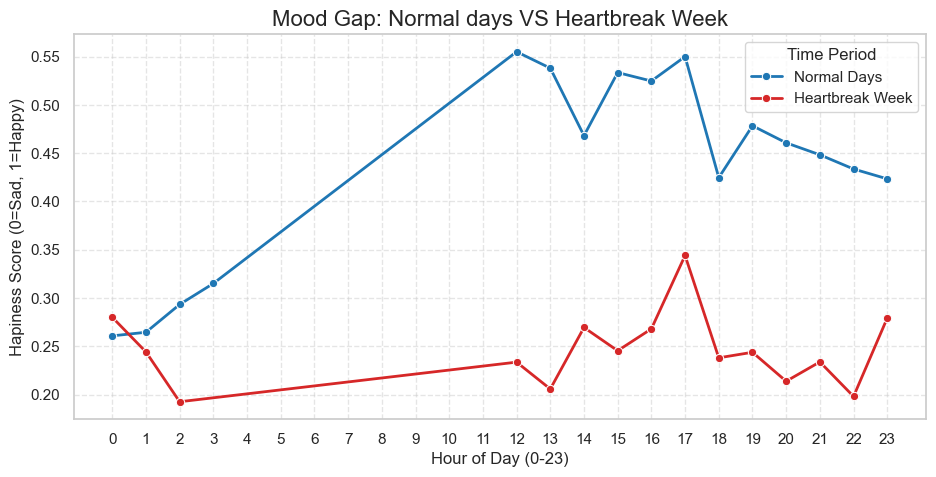

In [21]:
# --- CELL 3: THE HEARTBREAK REPORT (EDA) ---


# Separate listening activity into emotional disruption vs normal days
heartbreak_df = df[df['is_heartbreak_week'] == True]
normal_df = df[df['is_heartbreak_week'] == False]


# Compute average valence for each period
avg_heartbreak_valence = heartbreak_df['valence'].mean()
avg_normal_valence = normal_df['valence'].mean()

# Calculate percentage change in average happiness
percent_drop = ((avg_normal_valence - avg_heartbreak_valence) / avg_normal_valence) * 100


# Print numerical summary of the difference
print("Heartbreak Impact Report:")
print(f"Average Happiness during Normal Time: {avg_normal_valence:.2f}")
print(f"Average Hapiness during Heartbreak Time: {avg_heartbreak_valence:.2f}")
print(f"Happiness dropped by {percent_drop:.1f}% during this week.")


# Visualize valence differences across hours of the day
plt.figure(figsize=(11,5))

sns.lineplot(
    data=df,
    x='hour',
    y='valence',
    hue='is_heartbreak_week',
    palette={False: 'tab:blue', True: 'tab:red'},
    marker='o',
    linewidth=2,
    errorbar=None
)


# Chart styling for readability
plt.title("Mood Gap: Normal days VS Heartbreak Week", fontsize=16)
plt.xlabel("Hour of Day (0-23)")
plt.ylabel("Hapiness Score (0=Sad, 1=Happy)")
plt.legend(title="Time Period", labels=["Normal Days", "Heartbreak Week"])
plt.xticks(range(0,24))
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()


### Cell 4: Listening Patterns During the Heartbreak Period

After identifying a measurable drop in overall mood during the heartbreak period, this section shifts focus from aggregate trends to specific listening behavior.

Rather than analyzing emotional scores alone, the goal here is to examine which songs were played most frequently during this time. Repeated listening can reveal how emotional states influence not just overall mood, but also the tendency to return to certain tracks.

During the heartbreak period, the most frequently played songs largely cluster around lower-valence themes, suggesting a strong alignment between emotional state and listening choices. This concentration of repeated tracks reflects how listening behavior narrows during emotionally disruptive periods, with certain songs becoming more prominent as emotional anchors.

This section highlights how emotional shifts translate into concrete, observable listening patterns beyond summary statistics.


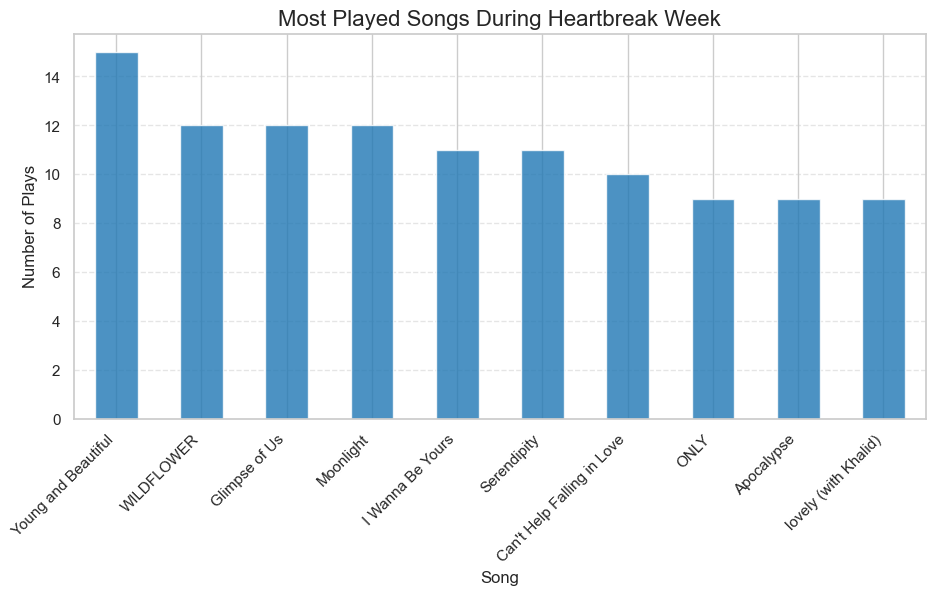

Top Repeated Songs During Heartbreak Week:


song_name
Young and Beautiful           15
WILDFLOWER                    12
Glimpse of Us                 12
Moonlight                     12
I Wanna Be Yours              11
Serendipity                   11
Can't Help Falling in Love    10
ONLY                           9
Apocalypse                     9
lovely (with Khalid)           9
Name: count, dtype: int64

In [22]:
# --- CELL 4: MOST PLAYED SONGS DURING HEARTBREAK WEEK ---


# Filter listening events to only the heartbreak period
heartbreak_songs = df[df['is_heartbreak_week'] == True]


# Count how many times each song was played
song_counts = (
    heartbreak_songs['song_name']
    .value_counts()
    .head(10)
)


# Display the results as a bar chart
plt.figure(figsize=(11,5))

song_counts.plot(
    kind='bar',
    color='tab:blue',
    alpha=0.8
)

plt.title("Most Played Songs During Heartbreak Week", fontsize=16)
plt.xlabel("Song")
plt.ylabel("Number of Plays")
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()


# Print the top repeated songs for reference
print("Top Repeated Songs During Heartbreak Week:")
display(song_counts)


### Cell 5: Determining the Number of Mood Clusters

Before grouping listening behavior into mood-based clusters, it is necessary to decide how many distinct clusters actually exist in the data.

This cell uses the Elbow Method to evaluate different cluster counts using only valence and energy, the two features that capture emotional characteristics of songs. Because clustering algorithms are sensitive to scale, these features are first standardized so that neither one dominates the distance calculations.

For each possible number of clusters (from 1 to 10), a K-Means model is trained and its inertia value is recorded. Inertia measures how tightly grouped the data points are within clusters. By plotting inertia against the number of clusters, the goal is to identify a point where adding more clusters results in diminishing improvements.

The “elbow” point in this plot is used as a practical choice for the number of mood clusters applied in the next step.


Testing cluster counts.....


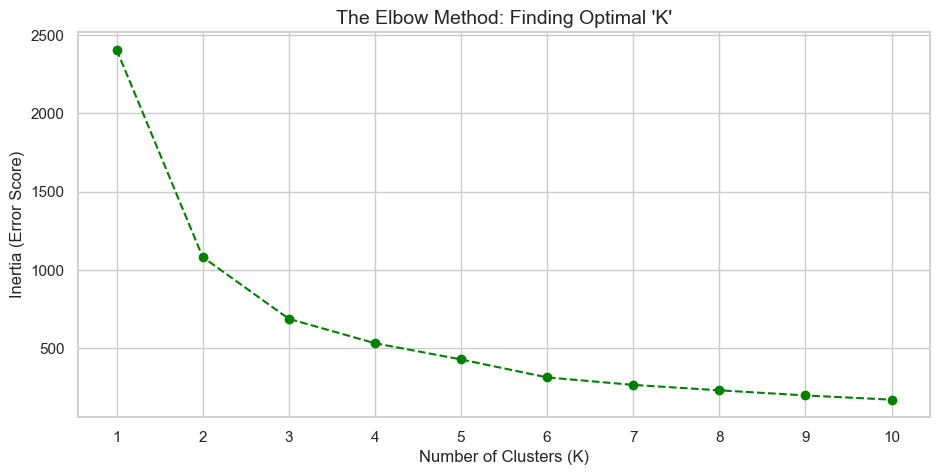

In [23]:
# --- CELL 5: FINDING THE OPTIMAL CLUSTERS (THE ELBOW METHOD) ---

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler


# Suppress non-critical system warnings for cleaner output
import warnings
warnings.filterwarnings('ignore')
import os
os.environ["OMP_NUM_THREADS"] = "1"


# Use valence and energy as inputs for clustering
features = df[['valence', 'energy']]


# Standardize features so both dimensions contribute equally
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)


# Evaluate different cluster counts using inertia
inertia = []
K_range = range(1,11)

print("Testing cluster counts.....")

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(scaled_features)
    inertia.append(kmeans.inertia_)


# Visualize inertia to identify the elbow point
plt.figure(figsize=(11,5))
plt.plot(K_range, inertia, marker='o', linestyle='--', color='green')

plt.title("The Elbow Method: Finding Optimal 'K'", fontsize=14)
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia (Error Score)")
plt.xticks(K_range)
plt.grid(True)

plt.show()


### Cell 6: Clustering Listening Behavior into Mood Personas

In this cell, the optimal number of clusters identified earlier (k=3) is applied to group listening behavior into distinct mood-based personas.

Using K-Means clustering with three clusters, each listening event is assigned to a group based on its valence and energy values. These clusters represent recurring emotional patterns in listening behavior rather than individual songs.

To make the results easier to interpret, each cluster is mapped to a descriptive mood label. A scatter plot is then used to visualize how these moods occupy different regions of the valence–energy space.

Finally, each mood cluster is profiled by examining its average happiness, average energy, size, and most frequent artists. This step helps translate abstract clusters into interpretable listening personas.


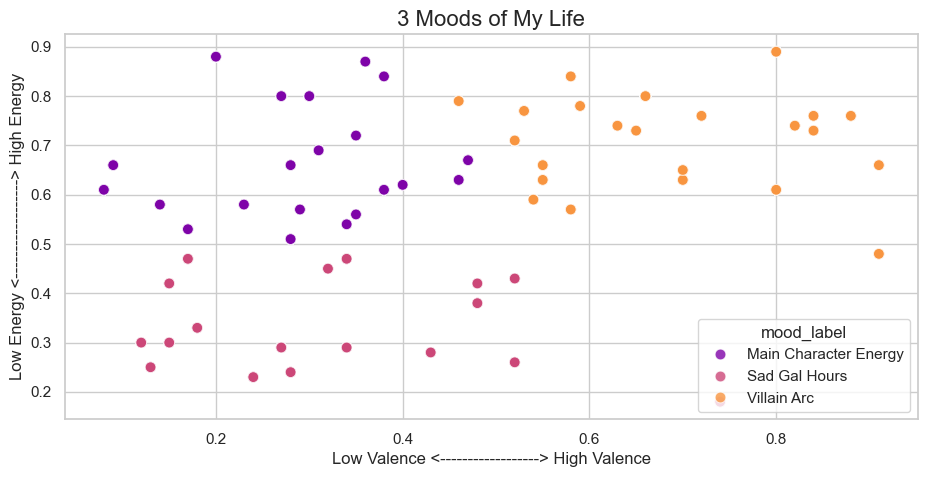

The 3 listening personas are.....

 Sad Gal Hours (408 plays): 
    - Average Happiness: 0.29
    - Average Energy: 0.33
    - Top Artists are: Billie Eilish, Lana Del Rey, Joji

 Main Character Energy (381 plays): 
    - Average Happiness: 0.27
    - Average Energy: 0.65
    - Top Artists are: Chase Atlantic, BTS, Ariana Grande

 Villain Arc (414 plays): 
    - Average Happiness: 0.68
    - Average Energy: 0.70
    - Top Artists are: Kendrick Lamar, Sachet-Parampara, Cardi B


In [24]:
# --- CELL 6: CLUSTERING & PROFILING ---


# Apply K-Means clustering using the selected number of clusters (k=3)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(scaled_features)


# Assign descriptive mood labels to each cluster
mood_names = {
    0: 'Sad Gal Hours',
    1: 'Main Character Energy',
    2: 'Villain Arc'
}

df['mood_label'] = df['cluster'].map(mood_names)


# Visualize mood clusters in valence–energy space
plt.figure(figsize=(11,5))

sns.scatterplot(
    data=df,
    x='valence',
    y='energy',
    hue='mood_label',
    palette='plasma',
    s=60,
    alpha=0.8
)

plt.title("3 Moods of My Life", fontsize=16)
plt.xlabel("Low Valence <------------------> High Valence")
plt.ylabel("Low Energy <------------------> High Energy")
plt.show()


# Profile each cluster to understand its characteristics
print("The 3 listening personas are.....")

for i in range(3):
    cluster_data = df[df['cluster'] == i]
    mood_name = mood_names[i]
    
    avg_val = cluster_data['valence'].mean()
    avg_eng = cluster_data['energy'].mean()
    size = len(cluster_data)

    top_artists = cluster_data['artist'].value_counts().head(3).index.tolist()

    print(f"\n {mood_name} ({size} plays): ")
    print(f"    - Average Happiness: {avg_val:.2f}")
    print(f"    - Average Energy: {avg_eng:.2f}")
    print(f"    - Top Artists are: {', '.join(top_artists)}")


### Cell 7: Learning to Recognize Mood Clusters

This cell trains a machine learning model to recognize the mood clusters identified in the previous step using valence and energy as inputs.

The goal here is not to predict future listening behavior, but to test whether the mood clusters discovered earlier are internally consistent and separable. If a model can reliably reproduce the cluster labels using only valence and energy, it suggests that the clustering step captured clear and stable patterns.

The dataset is split into training and testing sets so that model performance can be evaluated on unseen data. A Random Forest classifier is used due to its robustness and ability to handle non-linear decision boundaries.

The resulting accuracy reflects how well the model can recover the cluster assignments, serving as a validation of the clustering structure rather than a measure of real-world predictive power.


In [25]:
# --- CELL 7: TRAINING THE "MOODY DJ" (PREDICTION MODEL) ---

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report


# Define features and target labels
X = df[['valence','energy']]
y = df['cluster']


# Split data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


# Initialize and train the classifier
moody_dj = RandomForestClassifier(n_estimators=100, random_state=42)
moody_dj.fit(X_train, y_train)


# Predict cluster labels on unseen data
y_pred = moody_dj.predict(X_test)


# Evaluate model performance
accuracy = accuracy_score(y_test, y_pred) * 100

print(f"AI Model Accuracy: {accuracy:.2f}%")
print("Classification Report")
print(classification_report(y_test, y_pred))


AI Model Accuracy: 100.00%
Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        70
           1       1.00      1.00      1.00        83
           2       1.00      1.00      1.00        88

    accuracy                           1.00       241
   macro avg       1.00      1.00      1.00       241
weighted avg       1.00      1.00      1.00       241



### Cell 8: Exporting the Final Dataset

This final cell saves the results of the analysis for reuse outside this notebook.

By exporting the dataset with cluster assignments and mood labels included, the analysis becomes reproducible and easy to extend. The saved file can be used directly for visualization, further exploration, or integration into dashboards without needing to rerun the full pipeline.

This step marks the completion of the analysis workflow, preserving the insights generated in the previous sections in a single, ready-to-use dataset.


In [26]:
# --- CELL 8: EXPORTING THE FINAL DATASET ---

import os


# Ensure the output directory exists
os.makedirs('../data', exist_ok=True)


# Save the dataset with cluster and mood labels
df.to_csv('../data/spotify_data_clustered.csv', index=False)


print("Final dataset saved successfully!")
print(" - File: data/spotify_data_clustered.csv")


Final dataset saved successfully!
 - File: data/spotify_data_clustered.csv
